# EC6011 Group_13 - Python Code

# Importing Necessary Libraries

In [178]:
# Core Libraries
import numpy as np
import pandas as pd

# For Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

# For Time Series Analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf

# For Cointegration Test
from statsmodels.tsa.stattools import coint

# For Date and Time handling
from datetime import datetime

# For Statsmodels regression (for PPP tests)
import statsmodels.api as sm

# For Ignoring harmless warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [179]:
# Loading the Dataset
df = pd.read_excel(r"D:\Masters Study Abroad\BA 2nd Sem\EC6011 Business Forecasting\Group Project\Datasets\EC6011_Dataset.xlsx")

# Initial Dataset Inspection

In [180]:
# First Few Rows of the Dataset
df.head()

,Year/Month,CPI_Singapore,CPI_Switzerland,Nominal,Real
0,Jan 1999,62.9440,91.9000,117.6785,117.5758
1,Feb 1999,63.0220,92.2000,115.5185,115.5780
2,Mar 1999,62.8310,92.3000,114.3734,114.7207
3,Apr 1999,62.9940,92.5000,110.9686,111.0159
4,May 1999,63.1380,92.3000,110.1614,109.6400


In [181]:
# Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year/Month       314 non-null    object 
 1   CPI_Singapore    314 non-null    float64
 2   CPI_Switzerland  314 non-null    float64
 3   Nominal          314 non-null    float64
 4   Real             314 non-null    float64
dtypes: float64(4), object(1)
memory usage: 12.4+ KB


**Summary Statistics**

In [182]:
# Descriptive statistics
df.describe()

,CPI_Singapore,CPI_Switzerland,Nominal,Real
count,314.0000,314.0000,314.0000,314.0000
mean,78.2276,100.4576,129.5293,114.4451
std,11.2202,3.7024,12.3876,8.9775
min,62.8310,91.9000,95.3468,95.5062
25%,66.0277,98.2500,124.9330,108.1713
50%,81.3010,101.2000,131.7588,111.5483
75%,85.5185,102.2000,137.5671,121.6743
max,100.6770,108.7000,150.8569,140.7050


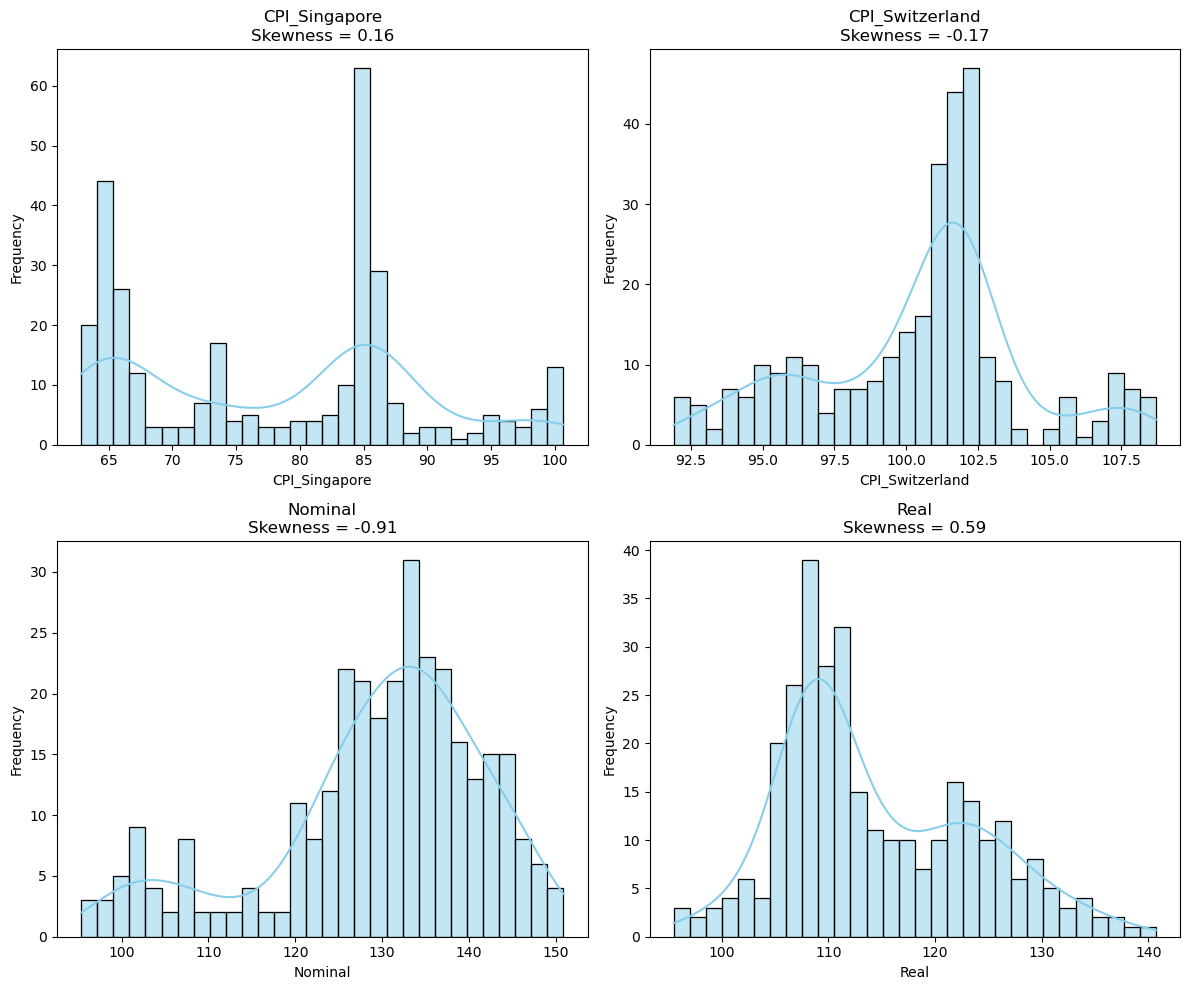

In [183]:
from scipy.stats import skew

# List of numeric columns
numeric_cols = ['CPI_Singapore', 'CPI_Switzerland', 'Nominal', 'Real']

# Set up the figure
plt.figure(figsize=(12, 10))

# Plot histogram with KDE and skewness annotation
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    skew_val = skew(df[col])
    plt.title(f'{col}\nSkewness = {skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Initial Dataset Modification

**Convert “Year/Month” to Ideal Time Series Format**

In [184]:
df.rename(columns={'Year/Month': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Preview
df.head()

,CPI_Singapore,CPI_Switzerland,Nominal,Real
Date,,,,
1999-01-01,62.9440,91.9000,117.6785,117.5758
1999-02-01,63.0220,92.2000,115.5185,115.5780
1999-03-01,62.8310,92.3000,114.3734,114.7207
1999-04-01,62.9940,92.5000,110.9686,111.0159
1999-05-01,63.1380,92.3000,110.1614,109.6400


**Renaming Columns for Ease of Access**

In [185]:
# Renaming columns for ease of access
df.rename(columns={
    'Nominal': 'neer',
    'Real': 'reer',
    'CPI_Singapore': 'cpi_foreign',
    'CPI_Switzerland': 'cpi_home'
}, inplace=True)

# Verifing the new column names
print(df.columns)

Index(['cpi_foreign', 'cpi_home', 'neer', 'reer'], dtype='object')


# Initial Data Analysis - Time Series

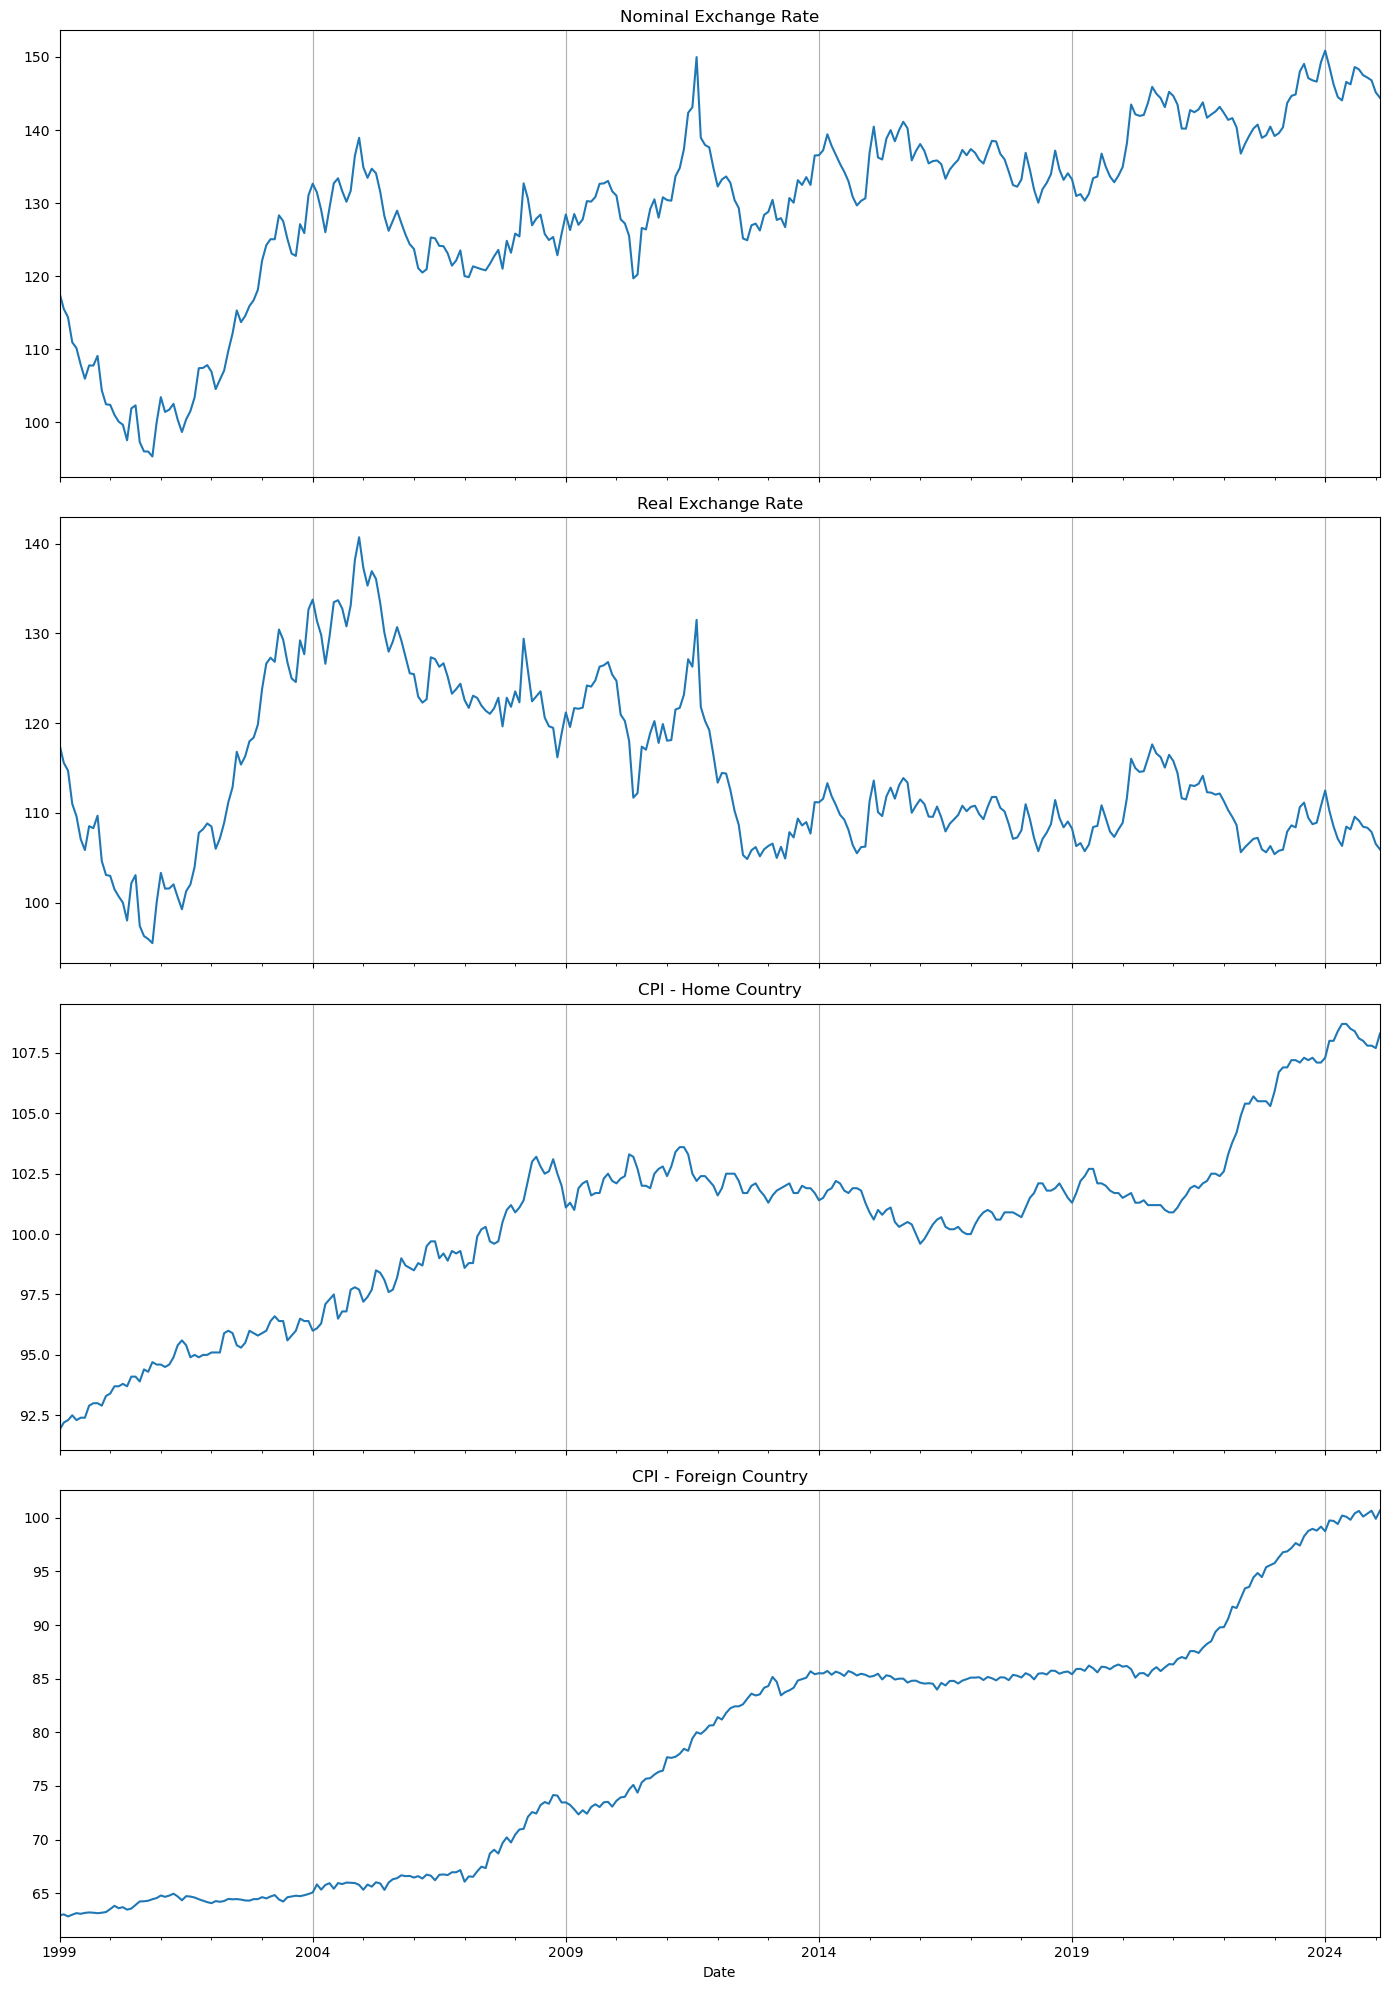

In [186]:
plt.style.use('default')

# Plot each column
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(14, 20), sharex=True)

df['neer'].plot(ax=axs[0], title='Nominal Exchange Rate')
axs[0].grid(True, axis='x')

df['reer'].plot(ax=axs[1], title='Real Exchange Rate')
axs[1].grid(True, axis='x')

df['cpi_home'].plot(ax=axs[2], title='CPI - Home Country')
axs[2].grid(True, axis='x')

df['cpi_foreign'].plot(ax=axs[3], title='CPI - Foreign Country')
axs[3].grid(True, axis='x')

plt.tight_layout()
plt.show()

# Log Transformations

In [187]:
# Checking if columns contain zeros or negative values
print((df[['neer', 'reer', 'cpi_home', 'cpi_foreign']] <= 0).sum())

neer           0
reer           0
cpi_home       0
cpi_foreign    0
dtype: int64


In [188]:
df['log_neer'] = np.log(df['neer'])
df['log_reer'] = np.log(df['reer'])
df['log_cpi_home'] = np.log(df['cpi_home'])
df['log_cpi_foreign'] = np.log(df['cpi_foreign'])

# Preview the columns
df[['log_neer', 'log_reer', 'log_cpi_home', 'log_cpi_foreign']].head()

,log_neer,log_reer,log_cpi_home,log_cpi_foreign
Date,,,,
1999-01-01,4.7680,4.7671,4.5207,4.1422
1999-02-01,4.7494,4.7499,4.5240,4.1435
1999-03-01,4.7395,4.7425,4.5250,4.1404
1999-04-01,4.7092,4.7097,4.5272,4.1430
1999-05-01,4.7019,4.6972,4.5250,4.1453


# Analysing the properties of the Log Variables created

**Log-Transformed Time Series with Trend and Moving Average**

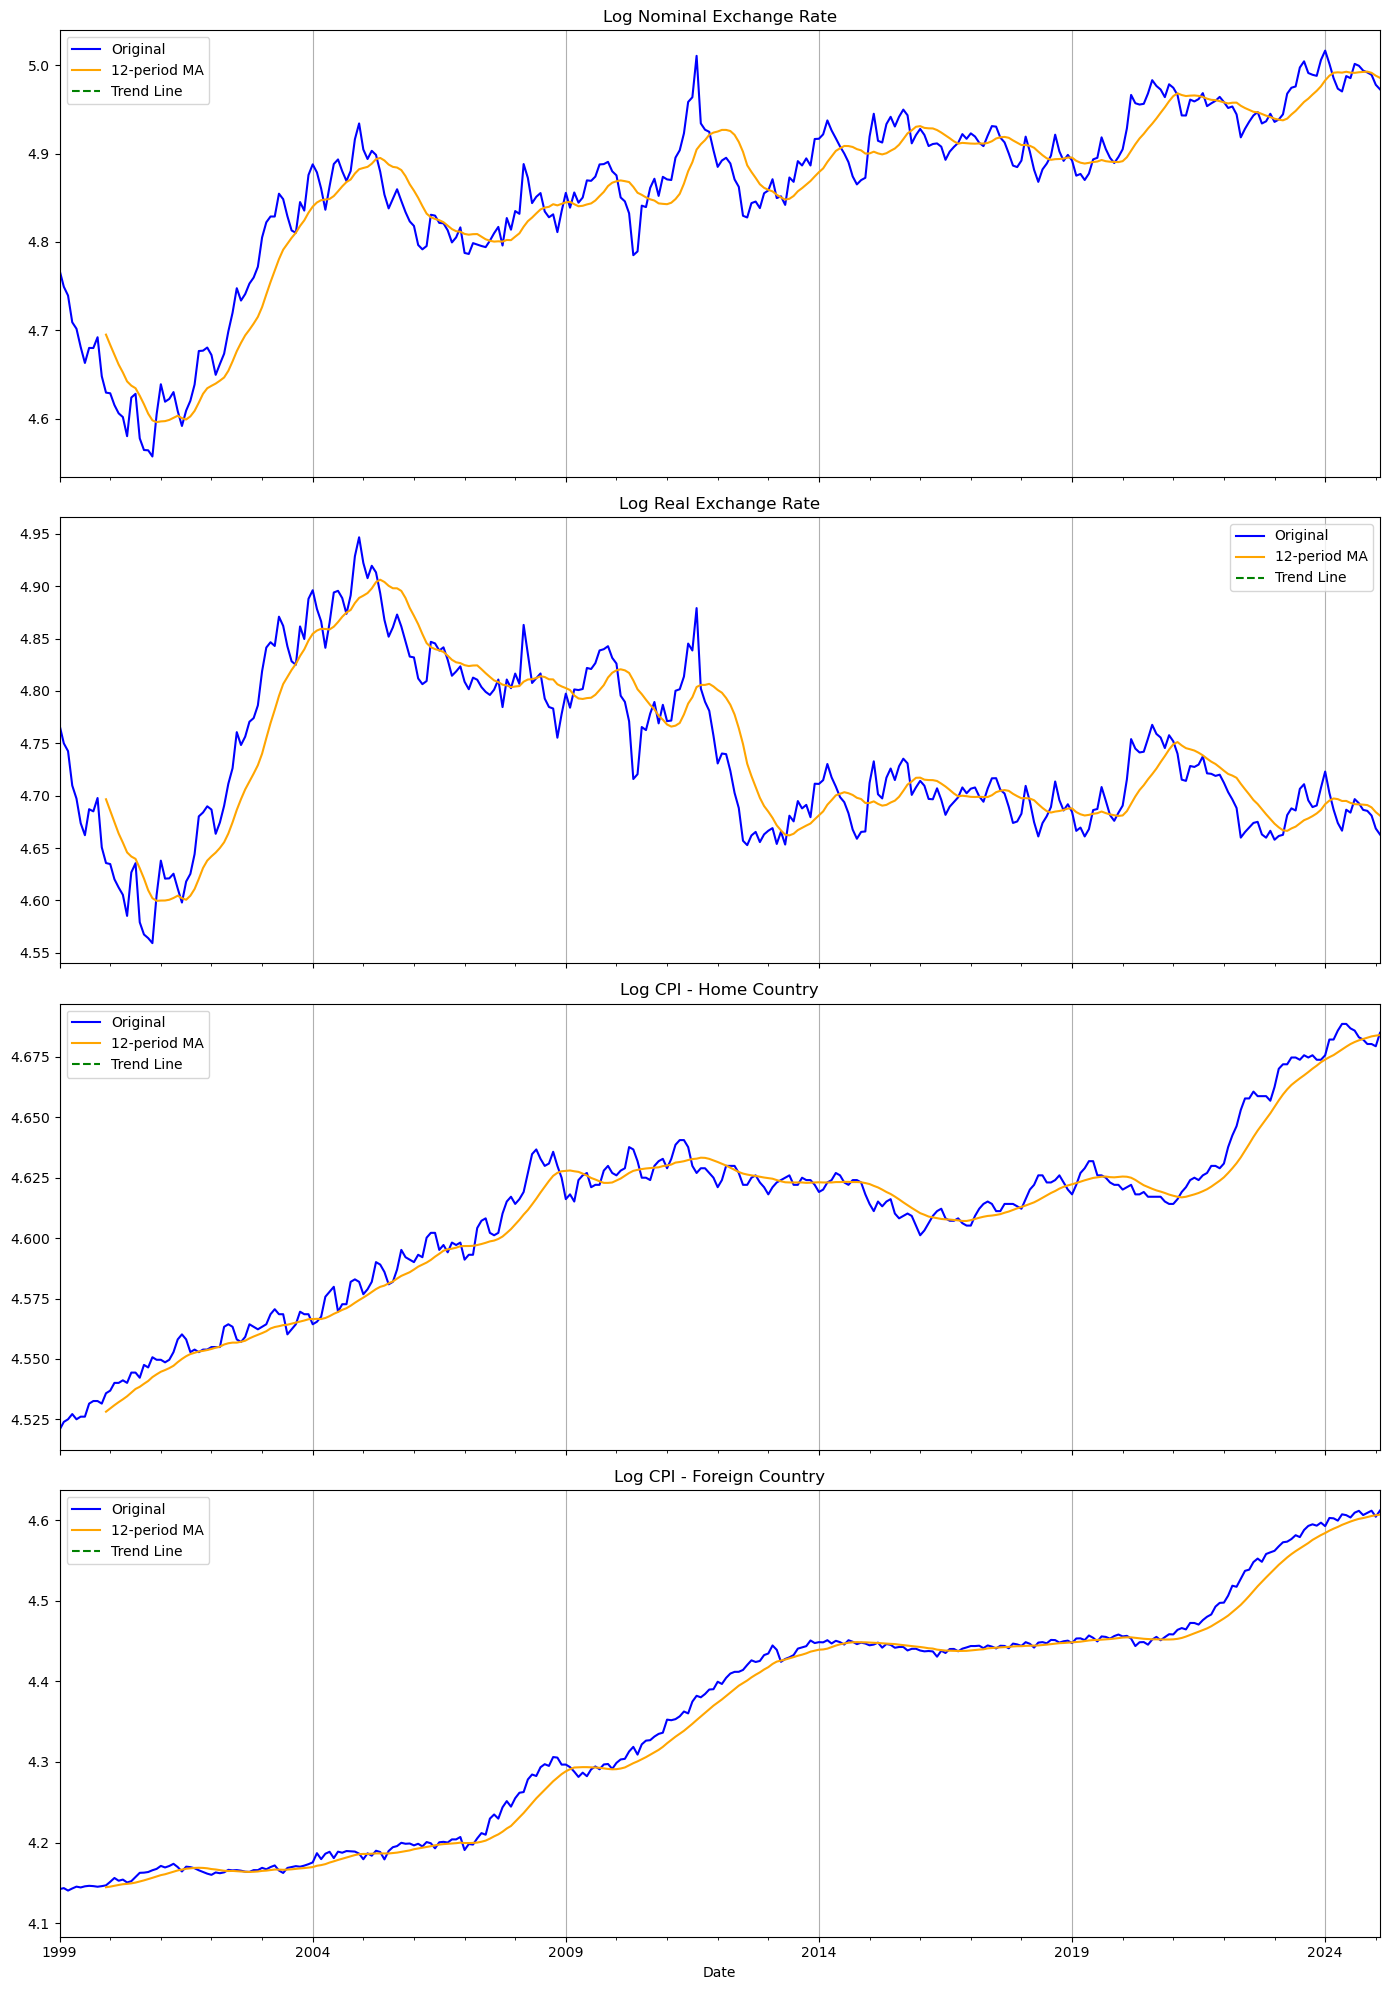

In [189]:
plt.style.use('default')
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(14, 20), sharex=True)

variables = ['log_neer', 'log_reer', 'log_cpi_home', 'log_cpi_foreign']
titles = ['Log Nominal Exchange Rate', 'Log Real Exchange Rate', 
          'Log CPI - Home Country', 'Log CPI - Foreign Country']

for i, var in enumerate(variables):
    # Plot original time series
    df[var].plot(ax=axs[i], label='Original', color='blue')
    
    # Moving average (adjust window as needed)
    df[var].rolling(window=12).mean().plot(ax=axs[i], label='12-period MA', color='orange')
    
    # Linear trend line
    x = np.arange(len(df[var]))
    y = df[var].values
    trend = np.polyfit(x, y, deg=1)
    axs[i].plot(df.index, np.polyval(trend, x), label='Trend Line', color='green', linestyle='--')
    
    axs[i].set_title(titles[i])
    axs[i].legend()
    axs[i].grid(True, axis='x')

plt.tight_layout()
plt.show()

**ADF Test – Stationarity Check**

In [190]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Test for {name}')
    print(f'  Test Statistic   : {result[0]:.4f}')
    print(f'  p-value          : {result[1]:.4f}')
    print(f'  # Lags Used      : {result[2]}')
    print(f'  # Observations   : {result[3]}')
    print('  Critical Values  :')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    print('  Result: ', 'Stationary (I(0))' if result[1] < 0.05 else 'Non-stationary')
    print('-' * 50)

In [191]:
# Running ADF test
adf_test(df['log_neer'], 'Log Nominal Exchange Rate')
adf_test(df['log_reer'], 'Log Real Exchange Rate')
adf_test(df['log_cpi_home'], 'Log CPI - Home Country')
adf_test(df['log_cpi_foreign'], 'Log CPI - Foreign Country')

ADF Test for Log Nominal Exchange Rate
  Test Statistic   : -1.4304
  p-value          : 0.5676
  # Lags Used      : 0
  # Observations   : 313
  Critical Values  :
    1%: -3.4514
    5%: -2.8708
    10%: -2.5717
  Result:  Non-stationary
--------------------------------------------------
ADF Test for Log Real Exchange Rate
  Test Statistic   : -1.8911
  p-value          : 0.3363
  # Lags Used      : 0
  # Observations   : 313
  Critical Values  :
    1%: -3.4514
    5%: -2.8708
    10%: -2.5717
  Result:  Non-stationary
--------------------------------------------------
ADF Test for Log CPI - Home Country
  Test Statistic   : -1.0267
  p-value          : 0.7434
  # Lags Used      : 14
  # Observations   : 299
  Critical Values  :
    1%: -3.4524
    5%: -2.8713
    10%: -2.5719
  Result:  Non-stationary
--------------------------------------------------
ADF Test for Log CPI - Foreign Country
  Test Statistic   : -0.2849
  p-value          : 0.9276
  # Lags Used      : 12
  # Observat

In [192]:
# Create first differences as they are all Non-stationary
df['dlog_neer'] = df['log_neer'].diff()
df['dlog_reer'] = df['log_reer'].diff()
df['dlog_cpi_home'] = df['log_cpi_home'].diff()
df['dlog_cpi_foreign'] = df['log_cpi_foreign'].diff()

# Drop NA from differencing
df_diff = df.dropna()

# ADF on first-differenced series
adf_test(df_diff['dlog_neer'], 'Diff Log Nominal Exchange Rate')
adf_test(df_diff['dlog_reer'], 'Diff Log Real Exchange Rate')
adf_test(df_diff['dlog_cpi_home'], 'Diff Log CPI - Home')
adf_test(df_diff['dlog_cpi_foreign'], 'Diff Log CPI - Foreign')

ADF Test for Diff Log Nominal Exchange Rate
  Test Statistic   : -13.0046
  p-value          : 0.0000
  # Lags Used      : 1
  # Observations   : 311
  Critical Values  :
    1%: -3.4516
    5%: -2.8709
    10%: -2.5717
  Result:  Stationary (I(0))
--------------------------------------------------
ADF Test for Diff Log Real Exchange Rate
  Test Statistic   : -12.7995
  p-value          : 0.0000
  # Lags Used      : 1
  # Observations   : 311
  Critical Values  :
    1%: -3.4516
    5%: -2.8709
    10%: -2.5717
  Result:  Stationary (I(0))
--------------------------------------------------
ADF Test for Diff Log CPI - Home
  Test Statistic   : -3.4395
  p-value          : 0.0097
  # Lags Used      : 13
  # Observations   : 299
  Critical Values  :
    1%: -3.4524
    5%: -2.8713
    10%: -2.5719
  Result:  Stationary (I(0))
--------------------------------------------------
ADF Test for Diff Log CPI - Foreign
  Test Statistic   : -3.0869
  p-value          : 0.0275
  # Lags Used      : 

**Autocorrelation Diagnostics Using ACF and PACF**

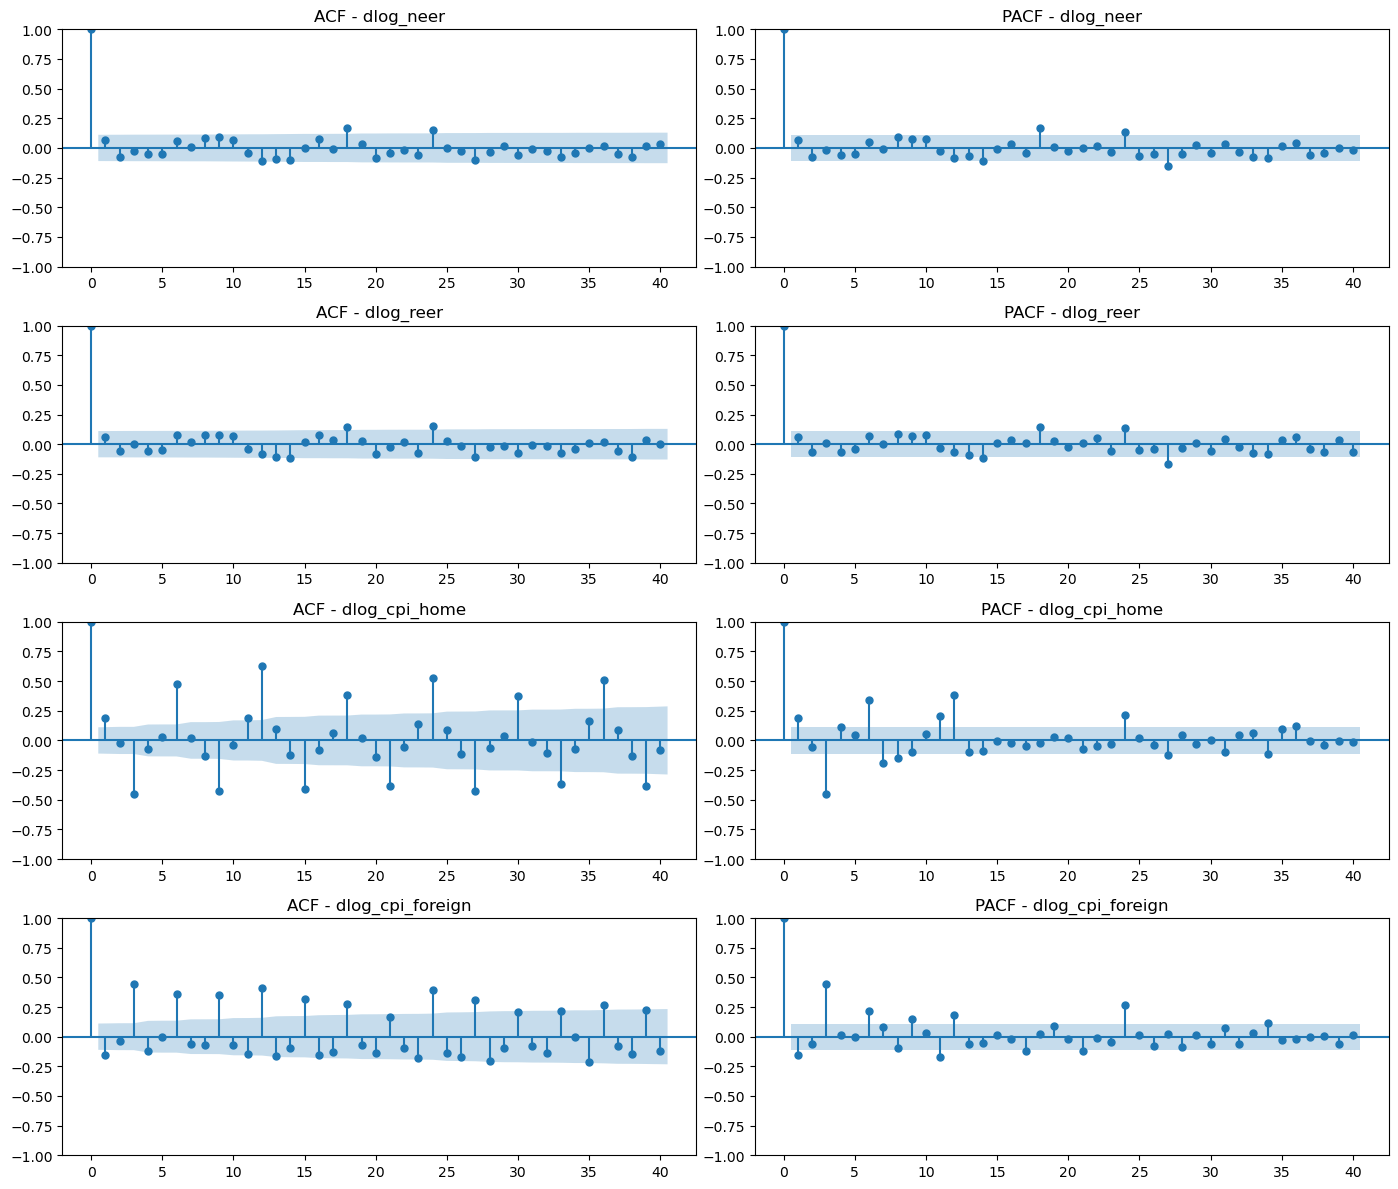

In [193]:
# List of differenced log-transformed variables
diff_vars = ['dlog_neer', 'dlog_reer', 'dlog_cpi_home', 'dlog_cpi_foreign']

# Create ACF and PACF plots
plt.style.use('default')
fig, axes = plt.subplots(len(diff_vars), 2, figsize=(14, 12))

for i, var in enumerate(diff_vars):
    # ACF plot
    plot_acf(df[var].dropna(), ax=axes[i, 0], lags=40, title=f'ACF - {var}')
    # PACF plot
    plot_pacf(df[var].dropna(), ax=axes[i, 1], lags=40, title=f'PACF - {var}', method='ywm')

plt.tight_layout()
plt.show()

# Testing Absolute form of Purchasing Power Parity

In [194]:
# Step 1: Create CPI differential
df['cpi_diff'] = df['log_cpi_home'] - df['log_cpi_foreign']

# Step 2: Run regression: log_neer ~ cpi_diff
X_abs = sm.add_constant(df['cpi_diff'])
y_abs = df['log_neer']
model_abs_ppp = sm.OLS(y_abs, X_abs).fit()

# Print regression summary
print(model_abs_ppp.summary())

# Step 3: Extract residuals and run ADF test
residuals_abs = model_abs_ppp.resid

# ADF Test Function
def adf_test(series, title=''):
    print(f"ADF Test for {title}")
    result = adfuller(series.dropna())
    print(f"  Test Statistic   : {result[0]:.4f}")
    print(f"  p-value          : {result[1]:.4f}")
    print(f"  # Lags Used      : {result[2]}")
    print(f"  # Observations   : {result[3]}")
    for key, val in result[4].items():
        print(f"    {key}%: {val:.4f}")
    if result[1] <= 0.05:
        print("Result: Stationary (reject H0)")
    else:
        print("Result: Non-stationary (fail to reject H0)")
    print("-" * 50)

# Run ADF on residuals
adf_test(residuals_abs, 'Residuals from Absolute PPP Regression')

                            OLS Regression Results                            
Dep. Variable:               log_neer   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     390.0
Date:                Fri, 11 Apr 2025   Prob (F-statistic):           6.94e-57
Time:                        12:52:35   Log-Likelihood:                 401.72
No. Observations:                 314   AIC:                            -799.4
Df Residuals:                     312   BIC:                            -791.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0321      0.010    526.566      0.0

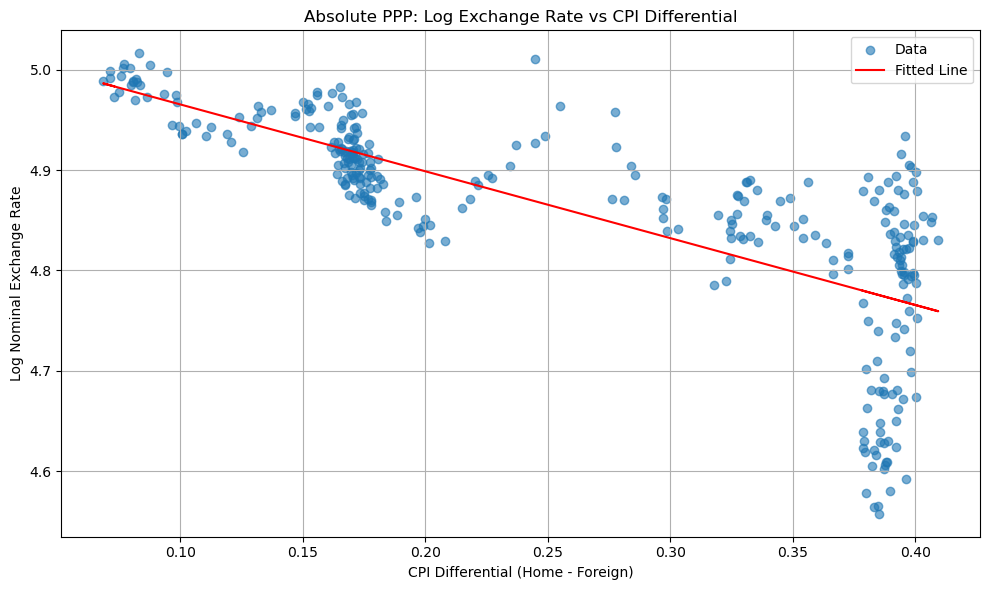

In [195]:
plt.figure(figsize=(10,6))
plt.scatter(df['cpi_diff'], df['log_neer'], alpha=0.6, label='Data')
plt.plot(df['cpi_diff'], model_abs_ppp.predict(X_abs), color='red', label='Fitted Line')
plt.title("Absolute PPP: Log Exchange Rate vs CPI Differential")
plt.xlabel("CPI Differential (Home - Foreign)")
plt.ylabel("Log Nominal Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Testing Realtive form of Purchasing Power Parity

In [196]:
# Drop NA rows for differenced data
df_diff = df.dropna()

# Step 1: Inflation differential
df_diff['inf_diff'] = df_diff['dlog_cpi_home'] - df_diff['dlog_cpi_foreign']

# Step 2: Regression: dlog_neer ~ inf_diff
X_rel = sm.add_constant(df_diff['inf_diff'])
y_rel = df_diff['dlog_neer']
model_rel_ppp = sm.OLS(y_rel, X_rel).fit()

# Print regression summary
print(model_rel_ppp.summary())

                            OLS Regression Results                            
Dep. Variable:              dlog_neer   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.094
Date:                Fri, 11 Apr 2025   Prob (F-statistic):              0.149
Time:                        12:52:35   Log-Likelihood:                 828.96
No. Observations:                 313   AIC:                            -1654.
Df Residuals:                     311   BIC:                            -1646.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.001      0.407      0.6

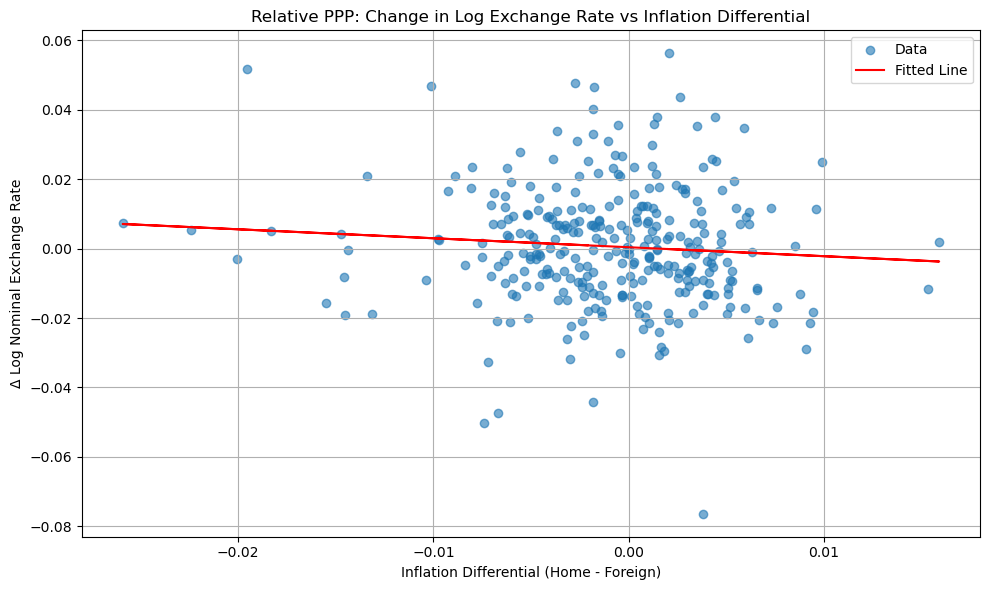

In [197]:
plt.figure(figsize=(10,6))
plt.scatter(df_diff['inf_diff'], df_diff['dlog_neer'], alpha=0.6, label='Data')
plt.plot(df_diff['inf_diff'], model_rel_ppp.predict(X_rel), color='red', label='Fitted Line')
plt.title("Relative PPP: Change in Log Exchange Rate vs Inflation Differential")
plt.xlabel("Inflation Differential (Home - Foreign)")
plt.ylabel("Δ Log Nominal Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ARIMA Modeling

**Box-Jenkins – Model Identification Using ACF & PACF**

**1 - Make the series stationary, this is done. log_reer is I(1) by using (log_reer)**

**ACF and PACF Plots**

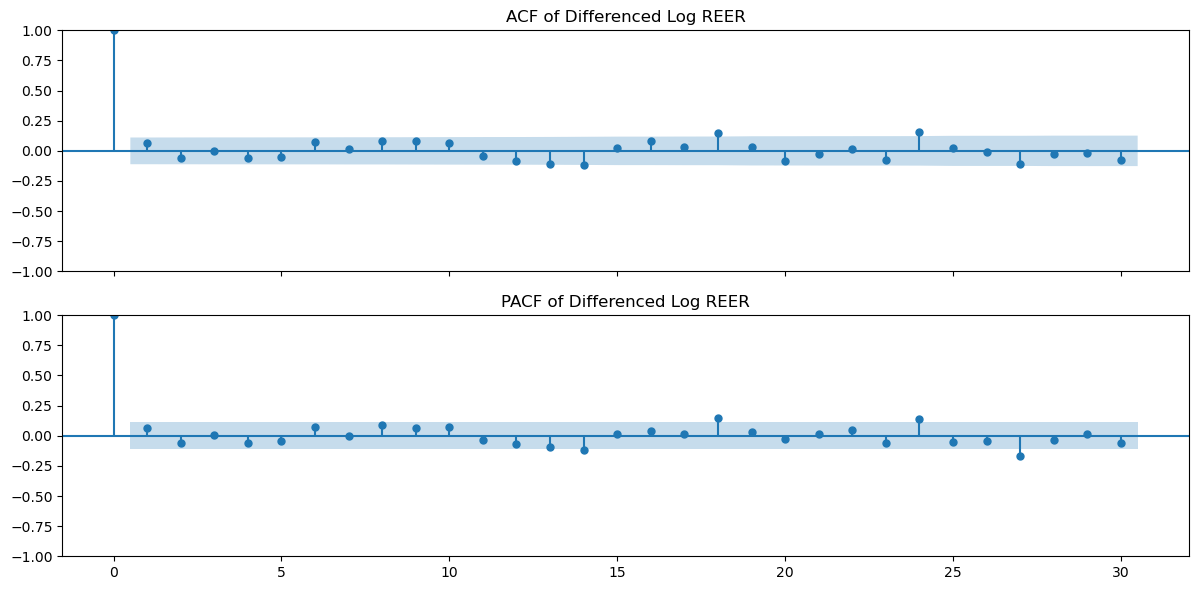

In [198]:
# Differenced series (REER is I(1), so we use its first difference)
reer_diff = df['log_reer'].diff().dropna()

# Plot ACF and PACF
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

plot_acf(reer_diff, lags=30, ax=axs[0])
axs[0].set_title('ACF of Differenced Log REER')
plot_pacf(reer_diff, lags=30, ax=axs[1])
axs[1].set_title('PACF of Differenced Log REER')

plt.tight_layout()
plt.show()

# Fitting ARIMA Models

**Fitting ARIMA(1,1,0) on log_reer**

In [199]:
# Fit ARIMA(1,1,0)
model_110 = ARIMA(df['log_reer'], order=(1, 1, 0))
results_110 = model_110.fit()

# Print summary
print(results_110.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 826.747
Date:                Fri, 11 Apr 2025   AIC                          -1649.494
Time:                        12:52:36   BIC                          -1642.002
Sample:                    01-01-1999   HQIC                         -1646.500
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0637      0.055      1.167      0.243      -0.043       0.171
sigma2         0.0003   1.83e-05     16.204      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-

**Fitting ARIMA(0,1,1) to log_reer**

In [200]:
# Fit ARIMA(0,1,1)
model_011 = ARIMA(df['log_reer'], order=(0, 1, 1))
results_011 = model_011.fit()

# Print summary
print(results_011.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 826.826
Date:                Fri, 11 Apr 2025   AIC                          -1649.652
Time:                        12:52:36   BIC                          -1642.159
Sample:                    01-01-1999   HQIC                         -1646.658
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0646      0.054      1.200      0.230      -0.041       0.170
sigma2         0.0003   1.83e-05     16.242      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-

**Fitting ARIMA(1,1,1) to log_reer**

In [201]:
# Fit ARIMA(1,1,1)
model_111 = ARIMA(df['log_reer'], order=(1, 1, 1))
results_111 = model_111.fit()

# Print summary
print(results_111.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 827.181
Date:                Fri, 11 Apr 2025   AIC                          -1648.361
Time:                        12:52:37   BIC                          -1637.123
Sample:                    01-01-1999   HQIC                         -1643.870
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5427      0.500     -1.084      0.278      -1.523       0.438
ma.L1          0.6073      0.469      1.294      0.196      -0.313       1.527
sigma2         0.0003   1.81e-05     16.352      0.0

**Fitting ARIMA(2,1,0) to log_reer**

In [202]:
model_210 = ARIMA(df['log_reer'], order=(2, 1, 0))
results_210 = model_210.fit()

# Print summary
print(results_210.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 827.348
Date:                Fri, 11 Apr 2025   AIC                          -1648.697
Time:                        12:52:37   BIC                          -1637.458
Sample:                    01-01-1999   HQIC                         -1644.206
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0664      0.055      1.211      0.226      -0.041       0.174
ar.L2         -0.0621      0.051     -1.220      0.222      -0.162       0.038
sigma2         0.0003   1.82e-05     16.235      0.0

**Fitting ARIMA(0,1,2) to log_reer**

In [203]:
# Fit ARIMA(0,1,2)
model_012 = ARIMA(df['log_reer'], order=(0, 1, 2))
results_012 = model_012.fit()

# Print summary
print(results_012.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(0, 1, 2)   Log Likelihood                 827.423
Date:                Fri, 11 Apr 2025   AIC                          -1648.847
Time:                        12:52:37   BIC                          -1637.608
Sample:                    01-01-1999   HQIC                         -1644.356
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0682      0.052      1.302      0.193      -0.035       0.171
ma.L2         -0.0637      0.051     -1.254      0.210      -0.163       0.036
sigma2         0.0003   1.83e-05     16.182      0.0

**Fitting ARIMA(2,1,2) to log_reer**

In [204]:
# Fit ARIMA(2,1,2)
model_212 = ARIMA(df['log_reer'], order=(2, 1, 2))
results_212 = model_212.fit()

# Print summary
print(results_212.summary())

                               SARIMAX Results                                
Dep. Variable:               log_reer   No. Observations:                  314
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 827.493
Date:                Fri, 11 Apr 2025   AIC                          -1644.985
Time:                        12:52:38   BIC                          -1626.254
Sample:                    01-01-1999   HQIC                         -1637.500
                         - 02-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3059      0.802      0.381      0.703      -1.266       1.878
ar.L2          0.1596      0.687      0.232      0.816      -1.187       1.506
ma.L1         -0.2374      0.777     -0.306      0.7

# ARIMA Model Comparison Table

In [205]:
from statsmodels.stats.diagnostic import acorr_ljungbox
df_clean = df.dropna()

orders = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0), (0, 1, 2), (2, 1, 2)]
comparison_dict = {}

for order in orders:
    model_name = f"ARIMA{order}"
    try:
        model = ARIMA(df_clean['log_reer'], order=order)
        result = model.fit()
        resid = result.resid

        # Ljung-Box Q-test
        q_stats = acorr_ljungbox(resid, lags=[4, 8, 12], return_df=True)

        # Coefficients and t-stats
        params = result.params
        tstats = result.tvalues

        stats_dict = {
            "a0": f"{params[0]:.4f} ({tstats[0]:.4f})" if len(params) > 0 else "",
            "a1": f"{params[1]:.4f} ({tstats[1]:.4f})" if len(params) > 1 else "",
            "a2": f"{params[2]:.4f} ({tstats[2]:.4f})" if len(params) > 2 else "",
            "b1": f"{params[3]:.4f} ({tstats[3]:.4f})" if len(params) > 3 else "",
            "b2": f"{params[4]:.4f} ({tstats[4]:.4f})" if len(params) > 4 else "",
            "AIC": round(result.aic, 4),
            "BIC": round(result.bic, 4),
            "Q(4)": round(q_stats['lb_stat'].iloc[0], 4),
            "Q(4) p": round(q_stats['lb_pvalue'].iloc[0], 4),
            "Q(8)": round(q_stats['lb_stat'].iloc[1], 4),
            "Q(8) p": round(q_stats['lb_pvalue'].iloc[1], 4),
            "Q(12)": round(q_stats['lb_stat'].iloc[2], 4),
            "Q(12) p": round(q_stats['lb_pvalue'].iloc[2], 4),
        }

        # Add to master comparison dict
        comparison_dict[model_name] = stats_dict

    except Exception as e:
        print(f"{model_name} failed: {e}")

# --- STEP 3: Format into Transposed Table ---
comparison_df = pd.DataFrame(comparison_dict).reset_index()
comparison_df.rename(columns={"index": "Term"}, inplace=True)

# --- STEP 4: Display Side-by-Side in Notebook ---
from IPython.display import display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\nARIMA Model Comparison Table:")
display(comparison_df)

# --- STEP 5: Save to Excel ---
comparison_df.to_excel("ARIMA_Model_Comparison_Transposed.xlsx", index=False)


ARIMA Model Comparison Table:


,Term,"ARIMA(1, 1, 0)","ARIMA(0, 1, 1)","ARIMA(1, 1, 1)","ARIMA(2, 1, 0)","ARIMA(0, 1, 2)","ARIMA(2, 1, 2)"
0,a0,0.0625 (1.1459),0.0719 (1.3366),-0.4746 (-0.9495),0.0641 (1.1696),0.0545 (1.0493),0.2744 (0.3800)
1,a1,0.0003 (16.2090),0.0003 (16.2569),0.5503 (1.1754),-0.0681 (-1.3318),-0.0691 (-1.3543),0.1200 (0.1918)
2,a2,,,0.0003 (16.3484),0.0003 (16.2440),0.0003 (16.1828),-0.2080 (-0.2987)
3,b1,,,,,,-0.2104 (-0.3360)
4,b2,,,,,,0.0003 (16.1073)
5,AIC,-1644.1457,-1644.3314,-1643.2690,-1643.5995,-1643.7290,-1639.9901
6,BIC,-1636.6597,-1636.8454,-1632.0400,-1632.3705,-1632.5000,-1621.2750
7,Q(4),0.0262,0.0261,0.0261,0.0267,0.0269,0.0264
8,Q(4) p,0.9999,0.9999,0.9999,0.9999,0.9999,0.9999
9,Q(8),0.0412,0.0411,0.0408,0.0417,0.0417,0.0409


# Best Model: ARIMA(0,1,1)

**Residual Diagnostics for ARIMA(0,1,1)**

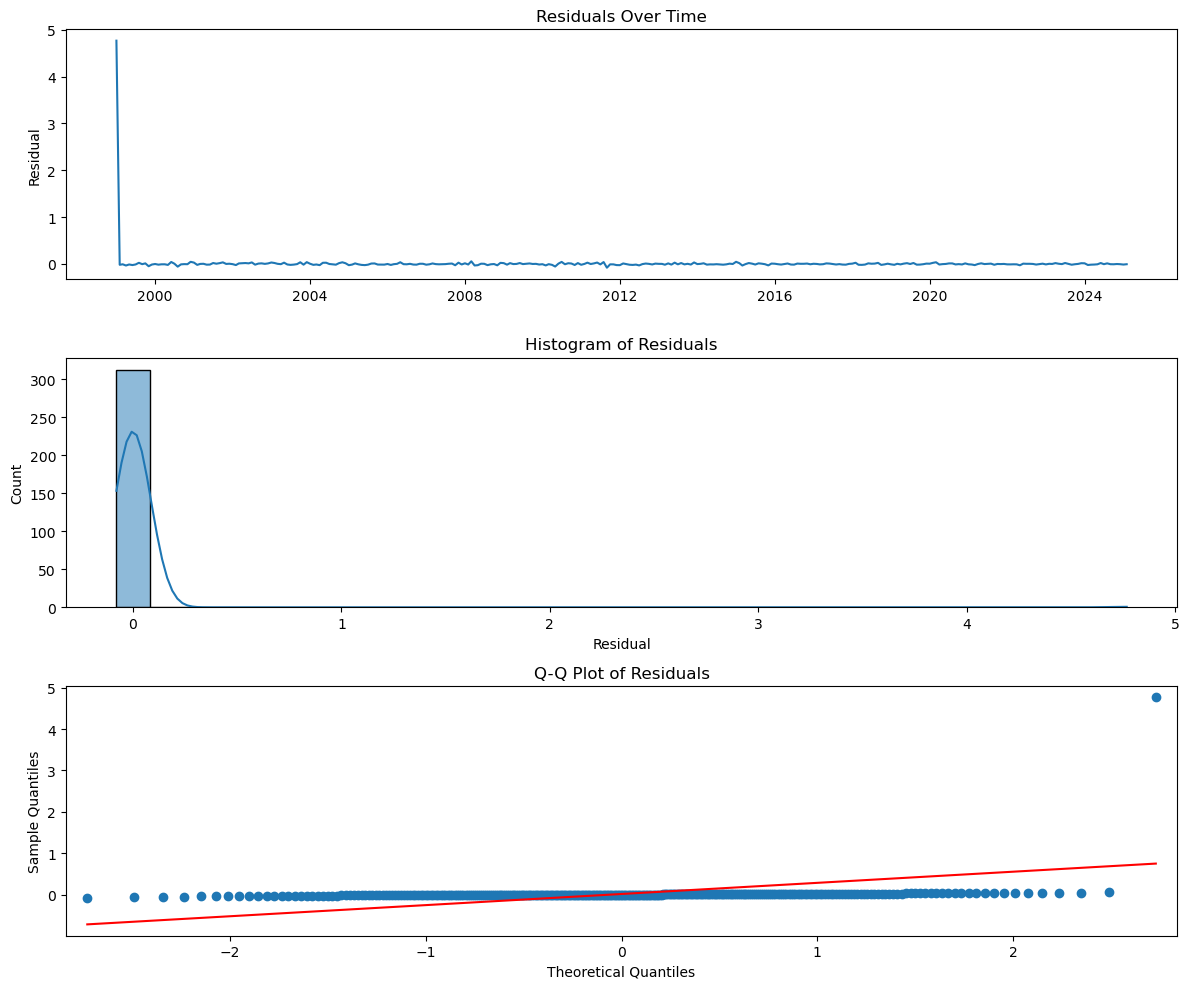

In [206]:
from statsmodels.graphics.gofplots import qqplot
residuals = results_011.resid

fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Time series of residuals
axs[0].plot(residuals)
axs[0].set_title("Residuals Over Time")
axs[0].set_ylabel("Residual")

# Histogram of residuals
sns.histplot(residuals, bins=30, kde=True, ax=axs[1])
axs[1].set_title("Histogram of Residuals")
axs[1].set_xlabel("Residual")

# Q-Q plot for normality
qqplot(residuals, line='s', ax=axs[2])
axs[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# Forecasting for the next 12 Months

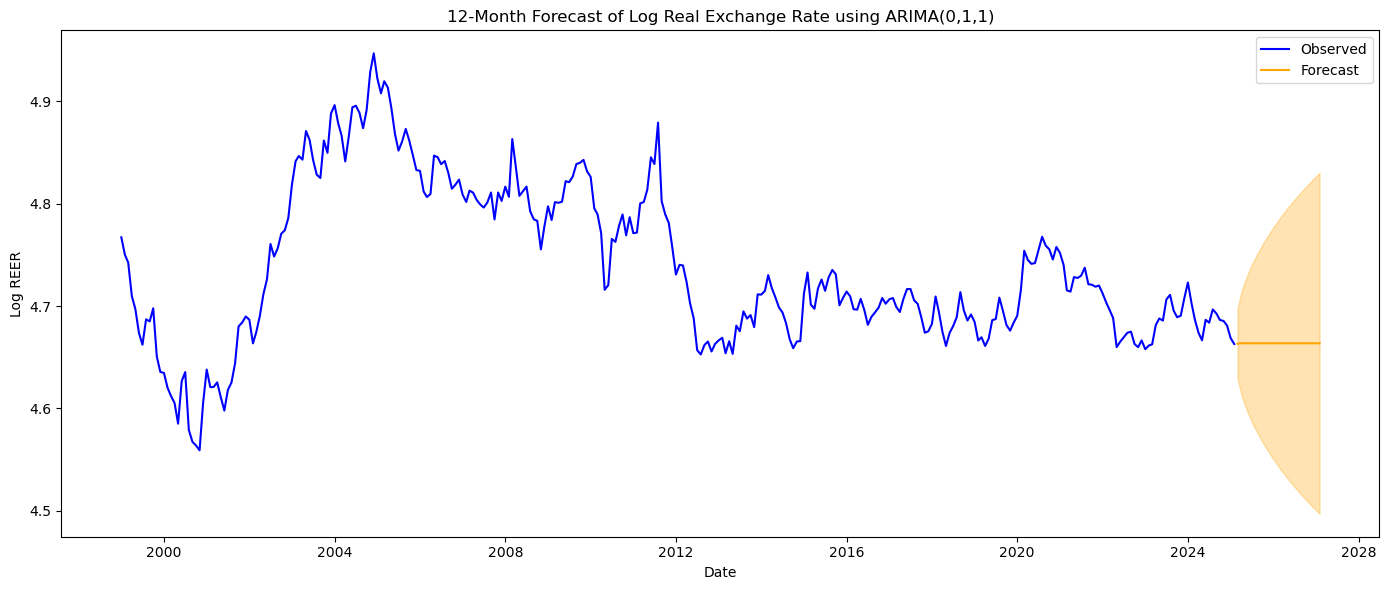

In [207]:
forecast_steps = 24
forecast_12 = results_011.get_forecast(steps=forecast_steps)

# Get mean and confidence intervals
forecast_mean = forecast_24.predicted_mean
conf_int = forecast_24.conf_int()

# Create future date index for plotting
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Plot forecast
plt.figure(figsize=(14, 6))
plt.plot(df['log_reer'], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean.values, label='Forecast', color='orange')
plt.fill_between(forecast_index, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values, color='orange', alpha=0.3)
plt.title('12-Month Forecast of Log Real Exchange Rate using ARIMA(0,1,1)')
plt.xlabel('Date')
plt.ylabel('Log REER')
plt.legend()
plt.tight_layout()
plt.show()

**Zoomed from 2024 Onward**

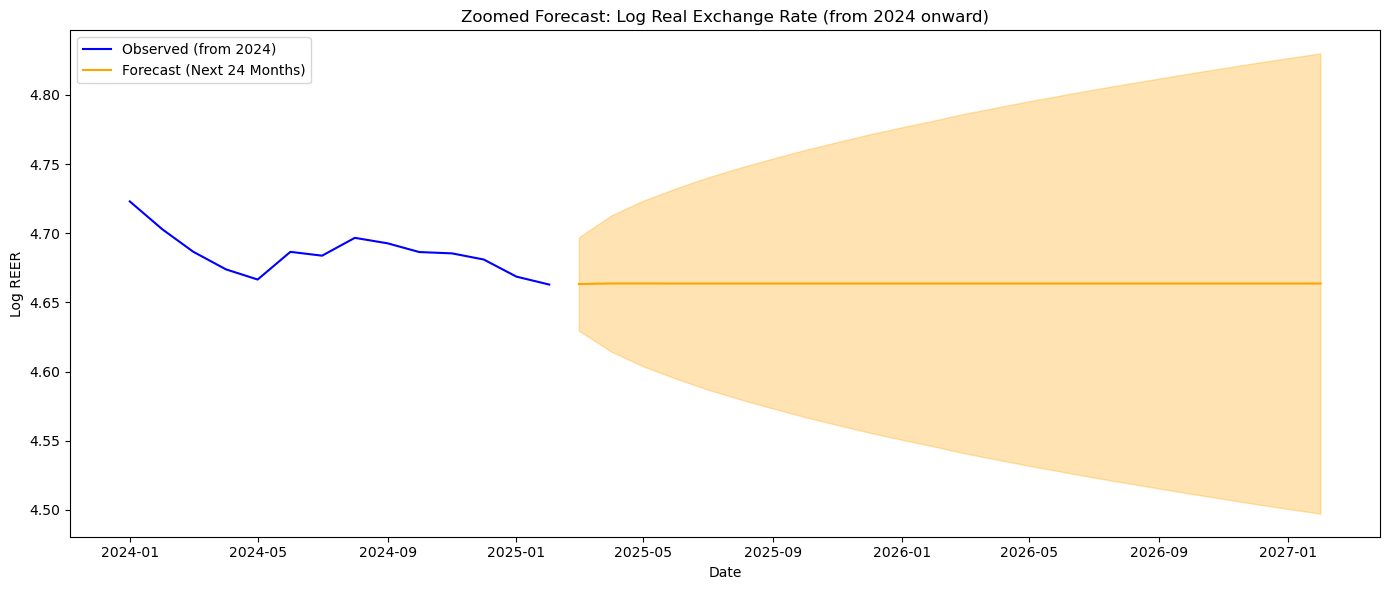

In [208]:
# To filter observed data from 2024 onwards
df_zoomed = df[df.index >= '2024-01-01']

# Combine the observed and forecast data for plotting
forecast_df = pd.DataFrame({
    'forecast': forecast_mean.values,
    'lower_ci': conf_int.iloc[:, 0].values,
    'upper_ci': conf_int.iloc[:, 1].values
}, index=forecast_index)

# Plot only the zoomed section (2024 onward)
plt.figure(figsize=(14, 6))
plt.plot(df_zoomed['log_reer'], label='Observed (from 2024)', color='blue')
plt.plot(forecast_df['forecast'], label='Forecast (Next 24 Months)', color='orange')
plt.fill_between(forecast_df.index, forecast_df['lower_ci'], forecast_df['upper_ci'], color='orange', alpha=0.3)
plt.title('Zoomed Forecast: Log Real Exchange Rate (from 2024 onward)')
plt.xlabel('Date')
plt.ylabel('Log REER')
plt.legend()
plt.tight_layout()
plt.show()